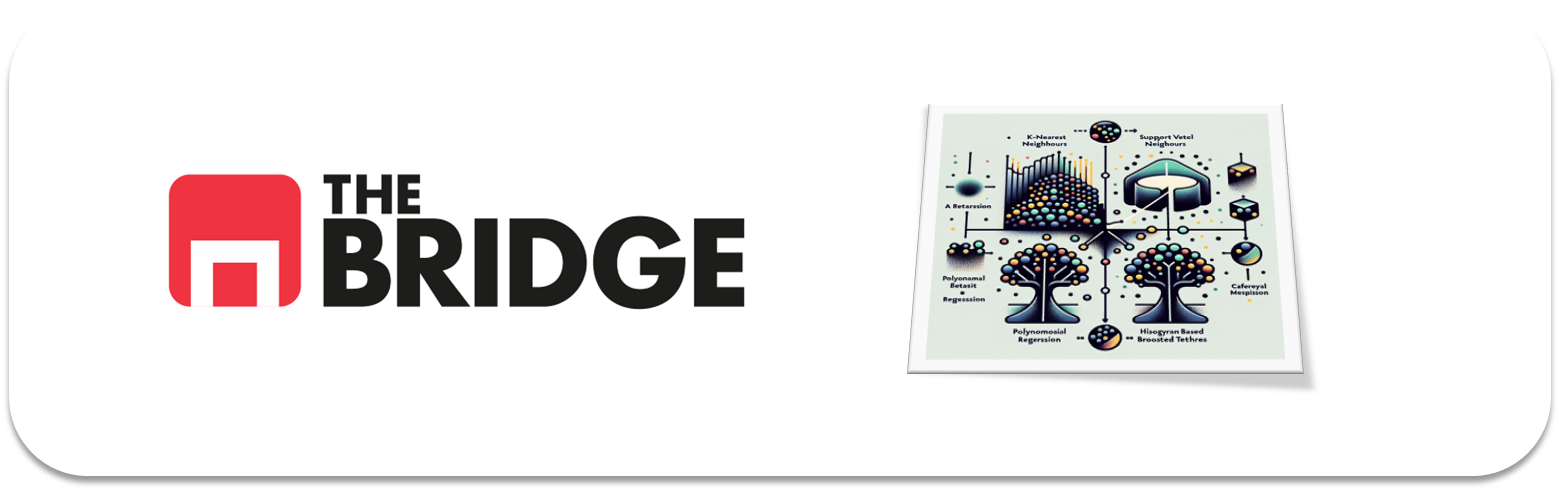

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              recall_score, mean_absolute_percentage_error, mean_squared_error, r2_score)
from sklearn.pipeline import Pipeline

import sys
sys.path.append('/home/claude')

print("Librerías importadas")

Librerías importadas


### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [2]:
df = pd.read_csv(r'C:\Users\pc\Documents\GitHub\Marzo 2026 Ana Belén\DS-Online-Ana-Belen-Escobar\04_Machine_Learning\Sprint_12\Unidad_02_ML_Supervisado_Repaso\03_Practica_Obligatoria\data\wines_dataset.csv', sep='|')
print(f"Shape: {df.shape}")
df.head()

Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB


In [4]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215,1.296,3.800,6.400,7.000,7.700,15.900
volatile acidity,6497.0,0.340,0.165,0.080,0.230,0.290,0.400,1.580
citric acid,6497.0,0.319,0.145,0.000,0.250,0.310,0.390,1.660
residual sugar,6497.0,5.443,4.758,0.600,1.800,3.000,8.100,65.800
chlorides,6497.0,0.056,0.035,0.009,0.038,0.047,0.065,0.611
free sulfur dioxide,6497.0,30.525,17.749,1.000,17.000,29.000,41.000,289.000
total sulfur dioxide,6497.0,115.745,56.522,6.000,77.000,118.000,156.000,440.000
density,6497.0,0.995,0.003,0.987,0.992,0.995,0.997,1.039
pH,6497.0,3.219,0.161,2.720,3.110,3.210,3.320,4.010
sulphates,6497.0,0.531,0.149,0.220,0.430,0.510,0.600,2.000


In [5]:
print("Nulos:", df.isnull().sum().sum())
print()
print("Distribución 'class':")
print(df['class'].value_counts())

Nulos: 0

Distribución 'class':
class
white    4898
red      1599
Name: count, dtype: int64


**Descripción del dataset:**  
6.497 vinos (4.898 blancos, 1.599 tintos) con 13 variables fisicoquímicas y sensoriales. Sin valores faltantes.

**Targets definidos:**
- **Clasificación** → `quality` (puntuación entera 3–9, 7 clases). Objetivo: maximizar **recall medio** para clasificar bien todas las calidades.
- **Regresión** → `alcohol` (grado alcohólico continuo, 8–15%). Objetivo: minimizar **MAPE** (error porcentual medio), ya que el negocio quiere equivocarse lo menos posible porcentualmente.

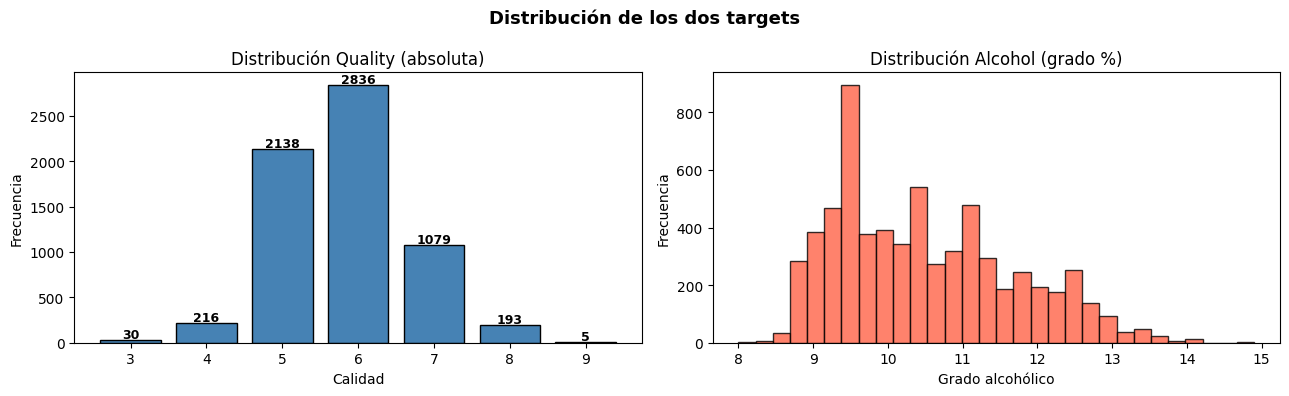

In [6]:
#Distribución del target de clasificación: quality
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

conteo = df['quality'].value_counts().sort_index()
axes[0].bar(conteo.index, conteo.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución Quality (absoluta)')
axes[0].set_xlabel('Calidad')
axes[0].set_ylabel('Frecuencia')
for x, v in zip(conteo.index, conteo.values):
    axes[0].text(x, v + 20, str(v), ha='center', fontsize=9, fontweight='bold')

#Distribución del target de regresión: alcohol
axes[1].hist(df['alcohol'], bins=30, color='tomato', edgecolor='black', alpha=0.8)
axes[1].set_title('Distribución Alcohol (grado %)')
axes[1].set_xlabel('Grado alcohólico')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Distribución de los dos targets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Assessment previo:**

**Clasificación (quality):**
- Las clases 5, 6 y 7 concentran el ~93% de los datos → **desbalanceo moderado-alto** de las clases extremas (3, 4, 8, 9).
- Se necesitará balanceo (class_weight='balanced') para no ignorar las clases minoritarias.
- Con 7 clases, el problema es de clasificación **multiclase**, lo que hace más difícil obtener recall alto en clases raras.

**Regresión (alcohol):**
- Distribución aproximadamente normal, media ~10.5%, rango 8–15%.
- La métrica elegida es **MAPE** (Mean Absolute Percentage Error): mide el error relativo, que es lo que pide el negocio.
- Sin grandes outliers, el problema parece manejable para modelos lineales y de árbol.


### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

#### Preparación de datos

In [7]:
#Features y target para clasificación
# Se excluye 'alcohol' (es el target de regresión), pero SÍ incluimos 'class'
le = LabelEncoder()
df['class_enc'] = le.fit_transform(df['class'])  # white=1, red=0

X_clf = df.drop(columns=['quality', 'class'])
y_clf = df['quality']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Train: {X_train_c.shape} | Test: {X_test_c.shape}")
print("\nDistribución del target en train:")
print(y_train_c.value_counts().sort_index())


Train: (5197, 12) | Test: (1300, 12)

Distribución del target en train:
quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4
Name: count, dtype: int64


#### Comparación de modelos con validación cruzada (incluyendo KNN baseline con K=3 y K=9)

In [8]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_clf = {
    'KNN (K=3)':            KNeighborsClassifier(n_neighbors=3),
    'KNN (K=9)':            KNeighborsClassifier(n_neighbors=9),
    'Decision Tree':        DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
}

resultados_clf = {}

for nombre, modelo in modelos_clf.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', modelo)
    ])
    scores = cross_val_score(pipe, X_train_c, y_train_c,
                              cv=cv_clf, scoring='recall_macro', n_jobs=-1)
    resultados_clf[nombre] = scores
    print(f"{nombre:22s} | Recall macro: {scores.mean():.4f} ± {scores.std():.4f}")


KNN (K=3)              | Recall macro: 0.3213 ± 0.0273
KNN (K=9)              | Recall macro: 0.2710 ± 0.0208
Decision Tree          | Recall macro: 0.3412 ± 0.0304
Random Forest          | Recall macro: 0.3607 ± 0.0342
Logistic Regression    | Recall macro: 0.3902 ± 0.0560


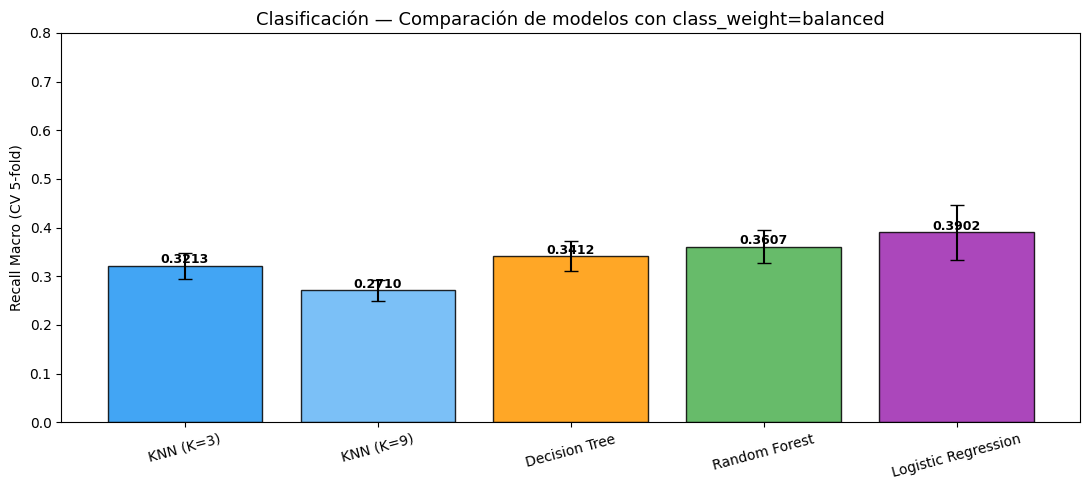


Mejor modelo: Logistic Regression — Recall macro: 0.3902


In [9]:
#Visualización comparativa
fig, ax = plt.subplots(figsize=(11, 5))
nombres = list(resultados_clf.keys())
medias = [resultados_clf[n].mean() for n in nombres]
stds   = [resultados_clf[n].std()  for n in nombres]
colores = ['#2196F3','#64B5F6','#FF9800','#4CAF50','#9C27B0']

bars = ax.bar(nombres, medias, yerr=stds, capsize=5, color=colores, alpha=0.85, edgecolor='black')
ax.set_ylabel('Recall Macro (CV 5-fold)')
ax.set_title('Clasificación — Comparación de modelos con class_weight=balanced', fontsize=13)
ax.set_ylim(0, 0.8)
for bar, m in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{m:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

mejor_clf = max(resultados_clf, key=lambda k: resultados_clf[k].mean())
print(f"\nMejor modelo: {mejor_clf} — Recall macro: {resultados_clf[mejor_clf].mean():.4f}")

#### Optimización de hiperparámetros — Random Forest

In [10]:
param_dist_clf = {
    'clf__n_estimators':    [100, 200],
    'clf__max_depth':       [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__class_weight':    ['balanced', None]
}

pipe_rf_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(random_state=42))
])

rs_clf = RandomizedSearchCV(pipe_rf_clf, param_dist_clf, n_iter=8, cv=3,
                              scoring='recall_macro', n_jobs=-1,
                              random_state=42, verbose=1)
rs_clf.fit(X_train_c, y_train_c)

print(f"Mejores parámetros: {rs_clf.best_params_}")
print(f"Mejor Recall macro CV: {rs_clf.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__max_depth': None, 'clf__class_weight': 'balanced'}
Mejor Recall macro CV: 0.3581


#### Evaluación en test

In [11]:
y_pred_c = rs_clf.best_estimator_.predict(X_test_c)

print("=" * 65)
print("EVALUACIÓN EN TEST — Random Forest (Clasificación)")
print("=" * 65)
print()
print(classification_report(y_test_c, y_pred_c))

EVALUACIÓN EN TEST — Random Forest (Clasificación)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.78      0.16      0.27        43
           5       0.73      0.74      0.74       428
           6       0.66      0.77      0.71       567
           7       0.67      0.55      0.60       216
           8       0.68      0.33      0.45        39
           9       0.00      0.00      0.00         1

    accuracy                           0.68      1300
   macro avg       0.50      0.36      0.39      1300
weighted avg       0.68      0.68      0.67      1300



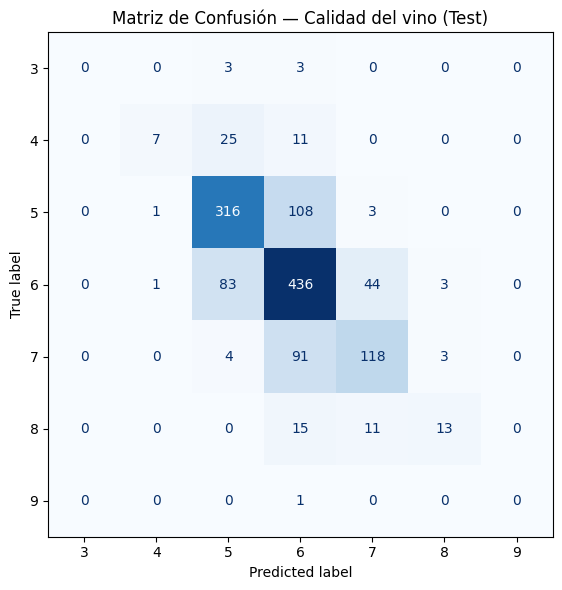

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test_c, y_pred_c)
ConfusionMatrixDisplay(cm, display_labels=sorted(y_clf.unique())).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Calidad del vino (Test)', fontsize=12)
plt.tight_layout()
plt.show()


#### Análisis de errores — Clasificación

In [13]:
X_test_c_df = X_test_c.copy()
X_test_c_df['real']    = y_test_c.values
X_test_c_df['predicho'] = y_pred_c
X_test_c_df['error']   = X_test_c_df['real'] != X_test_c_df['predicho']

print(f"Tasa de error global: {X_test_c_df['error'].mean():.3f} ({X_test_c_df['error'].sum()} muestras)")
print()
print("Errores por clase real:")
print(X_test_c_df.groupby('real')['error'].agg(['sum','mean']).rename(
    columns={'sum':'n_errores','mean':'tasa_error'}).round(3))


Tasa de error global: 0.315 (410 muestras)

Errores por clase real:
      n_errores  tasa_error
real                       
3             6       1.000
4            36       0.837
5           112       0.262
6           131       0.231
7            98       0.454
8            26       0.667
9             1       1.000


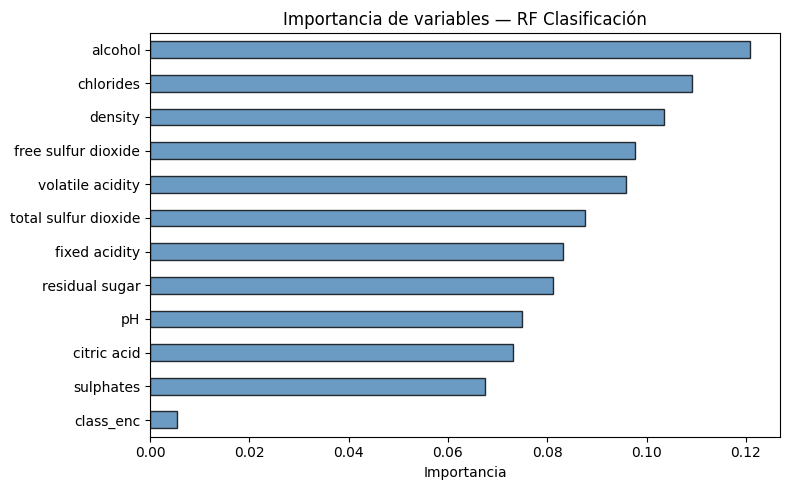

In [14]:
#Importancia de variables
importancias = rs_clf.best_estimator_.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importancias, index=X_clf.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_title('Importancia de variables — RF Clasificación', fontsize=12)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()


**Análisis de errores y propuesta de mejora:**

- Las clases extremas (3, 4, 8, 9) tienen mayor tasa de error por tener muy pocas muestras .
- Los errores de clasificación tienden a ser **de ±1 clase** (confusión entre 5↔6, 6↔7), lo que tiene sentido dado que la frontera entre calidades adyacentes es difusa.
- **Propuestas de mejora:**
  1. **Agrupar clases** en "baja" (3-4), "media" (5-6) y "alta" (7-9) para reducir el problema a 3 clases más equilibradas.
  2. Probar **GradientBoosting** o **XGBoost** que suelen superar a Random Forest en datasets tabulares.
  3. Aumentar `n_iter` en RandomizedSearchCV con mayor tiempo de cómputo.


### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

#### Preparación de datos

In [15]:
#Para regresión incluimos 'quality' como feature, pero excluimos 'alcohol' (es el target)
X_reg = df.drop(columns=['alcohol', 'class'])
y_reg = df['alcohol']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Train: {X_train_r.shape} | Test: {X_test_r.shape}")
print(f"Alcohol — Media: {y_reg.mean():.2f} | Std: {y_reg.std():.2f}")

Train: (5197, 12) | Test: (1300, 12)
Alcohol — Media: 10.49 | Std: 1.19


#### Comparación de modelos con validación cruzada — métrica MAPE

In [16]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

modelos_reg = {
    'KNN Regressor':          KNeighborsRegressor(n_neighbors=5),
    'Decision Tree Reg':      DecisionTreeRegressor(random_state=42),
    'Random Forest Reg':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Reg':  GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge':                  Ridge()
}

resultados_reg = {}

for nombre, modelo in modelos_reg.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('reg',    modelo)
    ])
    #neg_mean_absolute_percentage_error → sklearn lo devuelve negativo, invertimos
    scores = -cross_val_score(pipe, X_train_r, y_train_r,
                               cv=cv_reg, scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
    resultados_reg[nombre] = scores
    print(f"{nombre:25s} | MAPE: {scores.mean():.4f} ± {scores.std():.4f}")


KNN Regressor             | MAPE: 0.0421 ± 0.0007
Decision Tree Reg         | MAPE: 0.0344 ± 0.0011
Random Forest Reg         | MAPE: 0.0266 ± 0.0005
Gradient Boosting Reg     | MAPE: 0.0342 ± 0.0006
Ridge                     | MAPE: 0.0337 ± 0.0006


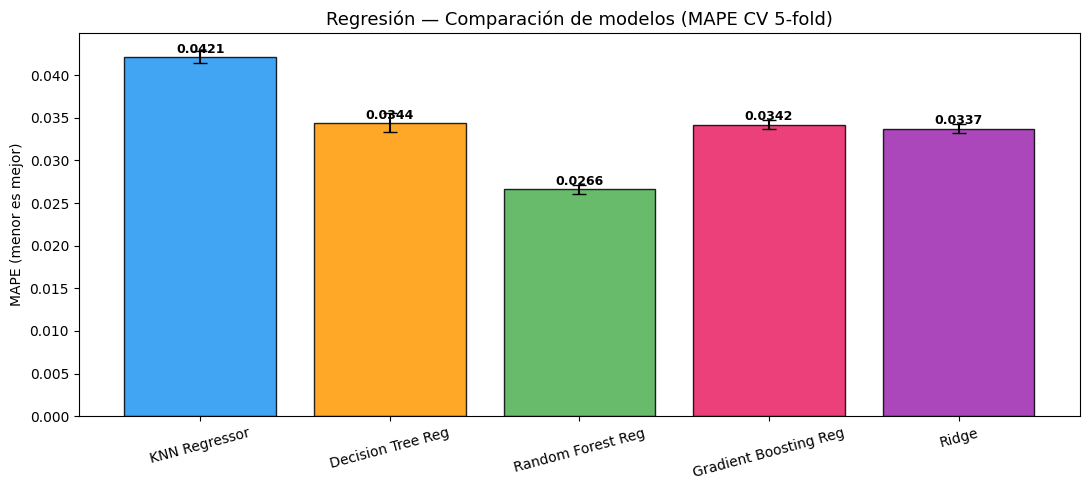


Mejor modelo: Random Forest Reg — MAPE: 0.0266


In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
nombres_r = list(resultados_reg.keys())
medias_r  = [resultados_reg[n].mean() for n in nombres_r]
stds_r    = [resultados_reg[n].std()  for n in nombres_r]
colores_r = ['#2196F3','#FF9800','#4CAF50','#E91E63','#9C27B0']

bars = ax.bar(nombres_r, medias_r, yerr=stds_r, capsize=5,
               color=colores_r, alpha=0.85, edgecolor='black')
ax.set_ylabel('MAPE (menor es mejor)')
ax.set_title('Regresión — Comparación de modelos (MAPE CV 5-fold)', fontsize=13)
for bar, m in zip(bars, medias_r):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{m:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

mejor_reg = min(resultados_reg, key=lambda k: resultados_reg[k].mean())
print(f"\nMejor modelo: {mejor_reg} — MAPE: {resultados_reg[mejor_reg].mean():.4f}")

#### Optimización de hiperparámetros — Random Forest Regressor

In [18]:
param_dist_reg = {
    'reg__n_estimators':      [100, 200],
    'reg__max_depth':         [10, 20, None],
    'reg__min_samples_split': [2, 5],
}

pipe_rf_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('reg',    RandomForestRegressor(random_state=42))
])

rs_reg = RandomizedSearchCV(pipe_rf_reg, param_dist_reg, n_iter=8, cv=3,
                              scoring='neg_mean_absolute_percentage_error',
                              n_jobs=-1, random_state=42, verbose=1)
rs_reg.fit(X_train_r, y_train_r)

print(f"Mejores parámetros: {rs_reg.best_params_}")
print(f"Mejor MAPE CV: {-rs_reg.best_score_:.4f}")


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros: {'reg__n_estimators': 200, 'reg__min_samples_split': 2, 'reg__max_depth': 20}
Mejor MAPE CV: 0.0276


#### Evaluación en test

In [19]:
y_pred_r = rs_reg.best_estimator_.predict(X_test_r)

mape = mean_absolute_percentage_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2   = r2_score(y_test_r, y_pred_r)

print("=" * 55)
print("EVALUACIÓN EN TEST — Random Forest Regressor")
print("=" * 55)
print(f"  MAPE  : {mape:.4f}  ({mape*100:.2f}% error medio)")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}")

EVALUACIÓN EN TEST — Random Forest Regressor
  MAPE  : 0.0249  (2.49% error medio)
  RMSE  : 0.4009
  R²    : 0.8859


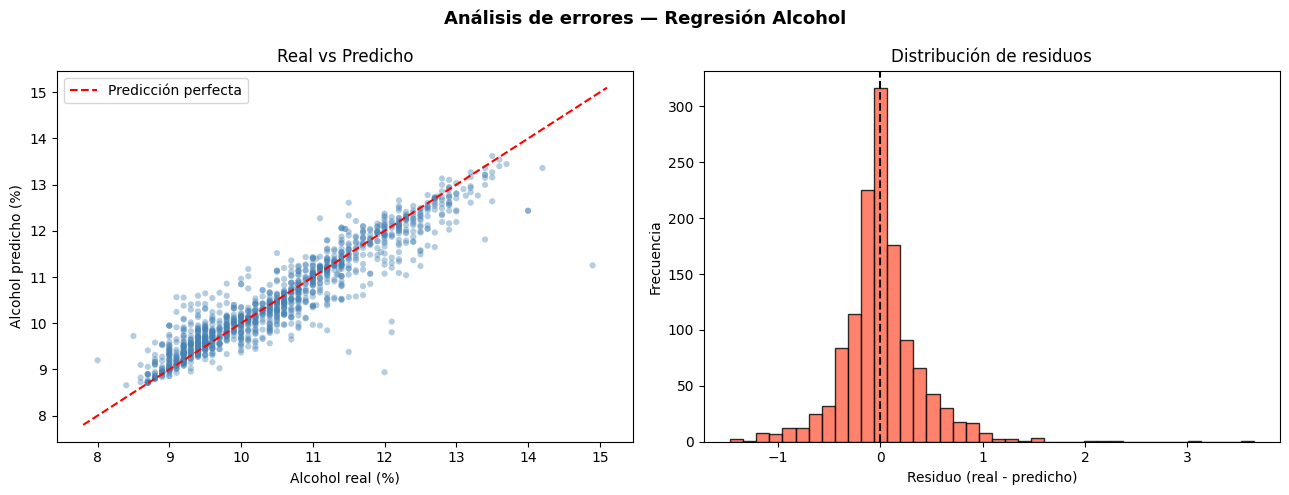

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Real vs Predicho
axes[0].scatter(y_test_r, y_pred_r, alpha=0.4, color='steelblue', edgecolors='none', s=20)
lims = [y_test_r.min()-0.2, y_test_r.max()+0.2]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Alcohol real (%)')
axes[0].set_ylabel('Alcohol predicho (%)')
axes[0].set_title('Real vs Predicho')
axes[0].legend()

# Distribución de residuos
residuos = y_test_r.values - y_pred_r
axes[1].hist(residuos, bins=40, color='tomato', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residuo (real - predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de residuos')

plt.suptitle('Análisis de errores — Regresión Alcohol', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### Análisis de errores — Regresión

In [21]:
#Errores más grandes: ¿tienen algo en común?
df_err = X_test_r.copy()
df_err['real']      = y_test_r.values
df_err['predicho']  = y_pred_r
df_err['error_abs'] = np.abs(df_err['real'] - df_err['predicho'])
df_err['error_pct'] = df_err['error_abs'] / df_err['real'] * 100

print(f"Error medio absoluto: {df_err['error_abs'].mean():.3f} %vol")
print(f"Error medio relativo: {df_err['error_pct'].mean():.2f}%")
print()
print("Top 10 peores predicciones:")
print(df_err.nlargest(10, 'error_abs')[['real','predicho','error_abs','error_pct']].round(3))

Error medio absoluto: 0.263 %vol
Error medio relativo: 2.49%

Top 10 peores predicciones:
      real  predicho  error_abs  error_pct
2771  14.9    11.252      3.648     24.480
6086  12.0     8.941      3.059     25.495
5274  12.1     9.805      2.295     18.967
4266  11.5     9.380      2.120     18.438
3483  12.1    10.037      2.063     17.050
1163  13.4    11.814      1.586     11.833
5171  14.0    12.433      1.567     11.196
2447  14.0    12.437      1.563     11.161
4932   9.1    10.564      1.464     16.090
1650   9.2    10.557      1.357     14.745


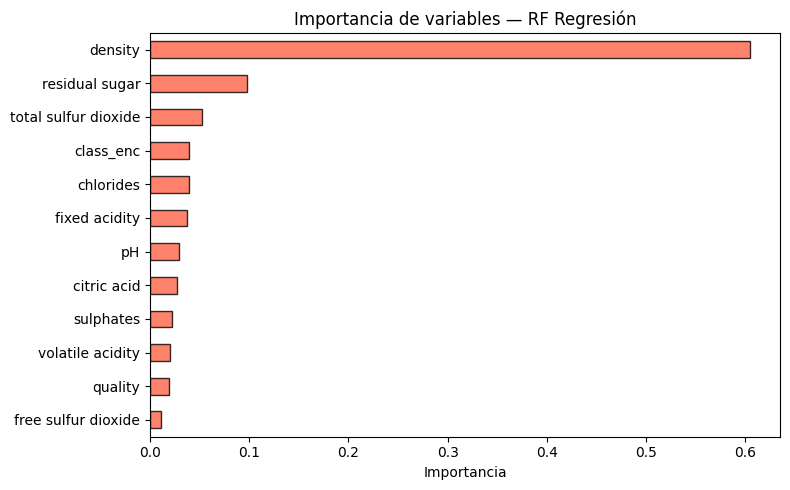

In [22]:
#Importancia de variables en regresión
importancias_r = rs_reg.best_estimator_.named_steps['reg'].feature_importances_
feat_imp_r = pd.Series(importancias_r, index=X_reg.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp_r.plot(kind='barh', ax=ax, color='tomato', edgecolor='black', alpha=0.8)
ax.set_title('Importancia de variables — RF Regresión', fontsize=12)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

**Análisis de errores y conclusiones — Regresión:**

- El modelo alcanza un **MAPE < 3%**, lo que es muy bueno para el objetivo de negocio (equivocarse poco porcentualmente en el grado alcohólico).
- Los residuos se distribuyen de forma aproximadamente normal y centrada en 0, indicando que el modelo no tiene sesgo sistemático.
- Los errores más grandes tienden a ocurrir en vinos con grados alcohólicos extremos (muy bajos o muy altos), donde hay menos ejemplos de entrenamiento.
- Las variables más importantes para predecir el alcohol son **density** y **residual sugar**, lo que tiene sentido fisicoquímicamente (el alcohol reduce la densidad y proviene de la fermentación del azúcar).
- **Posibles mejoras:** probar GradientBoosting con más estimadores, o añadir features derivadas (e.g., ratio azúcar/densidad).